# Reversibility from scratch

**Build a transformer that throws its activations away, and prove the gradients are
still exactly right.**

Training a transformer, memory goes on four things. Three of them — the weights, their
gradients, and the optimiser's moments — cost 16 bytes per parameter and *nothing else*.
They do not care how long your sequence is or how big your batch is. The fourth,
**activations**, cares about nothing else:

```text
                                   what it scales with
  weights                 2 bytes/param      -
  gradients               2 bytes/param      -
  Adam moments + master  12 bytes/param      -
  activations            ~12 tensors/layer   batch x sequence x depth   <- the problem
```

ZeRO (the previous session) splits the first three across GPUs and **explicitly leaves
activations alone**. Tensor, sequence, pipeline and context parallelism split the
computation, which divides activations across devices — but the total bill is unchanged,
only shared out. Reversibility is the only idea here that **deletes the term** instead
of dividing it, and it needs no second GPU to do it.

The trick: if a layer's input can be *recomputed* from its output, you never have to
store the input. Run the forward pass keeping only the last activation, and rebuild
everything on the way back down.

This notebook does that four ways, and — the part that matters — checks each one against
ordinary autograd in fp64. A reversible backward pass that is subtly wrong still trains;
it just trains to the wrong place. The only defence is a proof.

### How to read this

Each section is **why → the code → the evidence (asserted, not plotted) → what you should
see**, ending in a one-line **Takeaway**. Reading only the takeaways is a revision pass.

In [1]:
import os, sys, json, math, subprocess

# Colab: put the `revlm` package next to this notebook (upload the folder, or clone the
# repo and cd into 13_Distributed_Model_Pipeline_Parallel). Everything else is stock.
if not os.path.exists("revlm"):
    for parent in (".", "..", "../.."):
        if os.path.exists(os.path.join(parent, "revlm")):
            sys.path.insert(0, os.path.abspath(parent))
            break
    else:
        print("revlm/ not found - upload the package folder next to this notebook")

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from revlm.model import GPT, GPTConfig
from revlm import reversible as R
from revlm import metering as M
from revlm import plots

plots.style()
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} | device {DEV}")
if DEV == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"{p.name} | {p.total_memory/2**30:.2f} GiB")

torch 2.11.0+cu128 | device cuda
NVIDIA GeForce RTX 3070 Laptop GPU | 8.00 GiB


## 1. The problem, measured

Before any cleverness: how much does storing activations actually cost, and what does it
scale with? We hold the batch fixed and vary only the depth.

In [2]:
def per_batch_memory(mode, n_layer, batch=16, block=512):
    """Peak memory of one training step, minus the fixed weight/optimiser floor."""
    cfg = GPTConfig(n_layer=n_layer, block_size=block)
    torch.manual_seed(0)
    m = GPT(cfg, mode=mode).to(DEV)
    opt = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0.0)
    x = torch.randint(0, cfg.vocab_size, (batch, block), device=DEV)
    for _ in range(2):
        m(x, x).backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
    base = M.allocated_gib()
    m(x, x).backward(); opt.step(); opt.zero_grad(set_to_none=True)
    torch.cuda.synchronize()
    out = M.peak_gib() - base
    del m, opt, x; torch.cuda.empty_cache()
    return out

if DEV == "cuda":
    depths = [4, 8, 16, 32]
    stored = [per_batch_memory("store", L) for L in depths]
    for L, g in zip(depths, stored):
        print(f"  {L:2d} layers   {g:5.3f} GiB per batch")
    print(f"\n  4x the depth costs {stored[-1]/stored[0]:.2f}x the memory")

   4 layers   1.261 GiB per batch
   8 layers   1.746 GiB per batch
  16 layers   2.722 GiB per batch
  32 layers   4.671 GiB per batch

  4x the depth costs 3.70x the memory


**What you should see.** Memory grows almost exactly linearly in depth — because a
stored block keeps roughly a dozen intermediate tensors and nothing ever frees them
until backward has consumed them.

That linearity is the whole problem. It means depth and sequence length trade against
each other inside a fixed GPU, and it is why a 131k-token sequence needs terabytes.

**Takeaway.** Activation memory is `O(batch x sequence x depth)`, and it is the only
term in the budget that is.

## 2. A pre-LN transformer is already an Euler step

Here is the hinge the whole paper turns on. The standard block is

$$h_{l+1} = h_l + G_l(h_l)$$

where $G_l$ is the residual *branch* (attention + MLP, with a learnable scale
$\gamma_l$). Read that as a differential equation solved by the **explicit Euler
method** with step size 1:

$$\frac{dh}{dl} = G(h) \qquad\Longrightarrow\qquad h_{l+1} = h_l + \eta\, G_l(h_l)$$

The depth axis is *time*. Once you see a transformer as an ODE solver, "make it
reversible" stops being a trick and becomes a question about integrators: **which
integrators can be run backwards?**

In `revlm`, `Block` computes $G_l$ only — the residual add lives outside it, in the
integrator. That is what lets four different stacks share one definition of "what this
layer adds".

## 3. Attempt one: just invert it

The obvious move. Rearrange $h_{l+1} = h_l + G_l(h_l)$ for $h_l$:

$$h_l = h_{l+1} - G_l(h_l)$$

and notice the problem immediately: $G_l$ is evaluated at the thing we are solving for.
It is an *implicit* equation. The standard response is to iterate,

$$x^{(0)} = h_{l+1}, \qquad x^{(k+1)} = h_{l+1} - G_l(x^{(k)})$$

which converges **only if $G_l$ is a contraction**, that is $\mathrm{Lip}(G_l) < 1$.
Since $G_l = \gamma_l F_l$, the knob is $\gamma$. So: measure it.

In [3]:
def lipschitz_by_gamma(gammas, n_layer=4, batch=2, block=128):
    """max Lip(G_l) and the reconstruction error against iteration count, per gamma."""
    out = {}
    for g in gammas:
        cfg = GPTConfig(n_layer=n_layer, block_size=block, gamma_init=g)
        torch.manual_seed(0)
        m = GPT(cfg, mode="euler_implicit").to(DEV)
        h0 = m.embed(torch.randint(0, cfg.vocab_size, (batch, block), device=DEV))
        torch.manual_seed(7)
        out[g] = R.euler_implicit_report(m, h0, iters=(1, 2, 4, 8, 16, 32))
        del m
    return out

report = lipschitz_by_gamma([0.02, 0.05, 0.1, 0.25])
for g, rep in report.items():
    lip = max(rep["lipschitz"])
    errs = [f"{s['err']:.2e}" for s in rep["sweep"]]
    verdict = "contraction" if lip < 1 else "NOT a contraction"
    print(f"  gamma={g:<5} max Lip(G)={lip:5.2f}  {verdict:18s} err@K=1..32: {errs[0]} -> {errs[-1]}")

  gamma=0.02  max Lip(G)= 0.18  contraction        err@K=1..32: 4.77e-03 -> 9.77e-05
  gamma=0.05  max Lip(G)= 0.44  contraction        err@K=1..32: 2.50e-02 -> 3.91e-04
  gamma=0.1   max Lip(G)= 0.88  contraction        err@K=1..32: 6.83e-02 -> 6.99e-02
  gamma=0.25  max Lip(G)= 2.20  NOT a contraction  err@K=1..32: 2.16e-01 -> 2.44e-01


**What you should see.** A clean threshold. Below $\mathrm{Lip}(G)=1$ the error collapses
towards zero as you iterate; above it, iterating does not help at all — the error at 32
steps is no better than at 1.

And the default $\gamma = 0.1$ lands *almost exactly on the line*. At the real model size
(`d=384`, `T=512`) $\mathrm{Lip}(G) \approx 1.05$: the iteration neither converges nor
explodes, it **stalls**, leaving a reconstruction error around 0.09 forever.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight medium, now using 400.


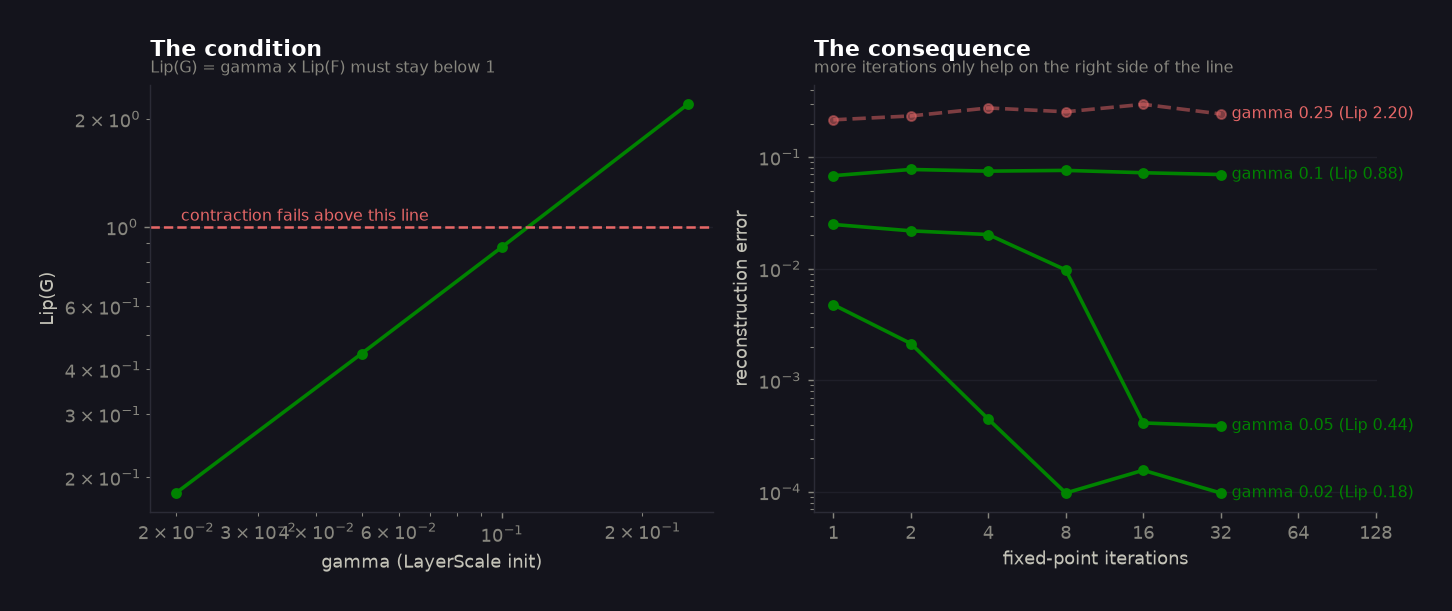

In [4]:
from IPython.display import Image, display
OUT = "assets" if os.path.isdir("assets") else "."
display(Image(plots.euler_condition(report, OUT)))

So implicit Euler is not impossible — it is **conditional**. Two reasons that is still
bad news:

1. **$\gamma$ is a learnable parameter.** Nothing in AdamW knows about the constraint. A
   run can start inside the convergent region and walk out of it, and when it does, the
   reconstruction silently stops matching, the gradients quietly become wrong, and the
   loss keeps going down anyway.
2. **The safe region is not a property of the method.** $\mathrm{Lip}$ depends on width
   and sequence length too — at `d=16` it is ~0.04 and everything looks fine. A unit test
   on a toy model *certifies a method that cannot train at real width.*

> **A measurement trap worth keeping.** An earlier version of `contraction_estimate`
> used finite differences, $(G(x+\epsilon v) - G(x))/\epsilon$, and reported
> $\mathrm{Lip} \approx 80$ instead of $\approx 1$. Under bf16 autocast at
> $\epsilon = 10^{-3}$ that subtraction cancels away every significant digit, and
> dividing by $\epsilon$ turns the remaining noise into a number. A 50x overestimate,
> entirely believable, and it would have condemned a method that actually sits right on
> the boundary. `contraction_estimate` uses exact autograd VJPs.

**Takeaway.** Inverting Euler directly needs $\gamma \cdot \mathrm{Lip}(F) < 1$, a
condition nothing enforces and which depends on the model, not the method. We need
integrators that are reversible *unconditionally*.

## 4. Attempt two: symplectic Euler — give the stream a velocity

The reason Euler is hard to invert is that one state has to do two jobs. Add a second:

$$v_{l+1} = v_l + G_l(h_l), \qquad h_{l+1} = h_l + v_{l+1}, \qquad v_0 = 0$$

Now run it backwards, and watch every right-hand side be something we already know:

$$h_l = h_{l+1} - v_{l+1}, \qquad v_l = v_{l+1} - G_l(h_l)$$

Explicit both ways. No iteration, no condition, exact to floating point. One evaluation
of $G$ per layer on the way back — and that same evaluation also supplies the gradient,
so nothing is computed twice. (This is the Momentum-ResNet construction: momentum is
what buys the invertibility.)

## 5. Attempt three: midpoint / leapfrog — keep two states in time

The other way to get a second state is to remember where you *were*:

$$h_{l+1} = h_{l-1} + 2\,G_l(h_l)$$

bootstrapped with one Euler step $h_1 = h_0 + G_0(h_0)$. The inverse reads straight off:

$$h_{l-1} = h_{l+1} - 2\,G_l(h_l)$$

with $G_l$ evaluated at $h_l$, which we have. Exact, explicit, one evaluation per layer.
This is the variant the session recommends, and it is second-order accurate as an
integrator where symplectic Euler is first-order.

Its known pathology: the even- and odd-indexed chains are coupled only through $G$, and
can drift apart — the *parasitic mode*. We track it rather than damp it, because the
usual damping (a Robert–Asselin filter) would destroy the exact reversibility that is
the entire point.

## 6. Attempt four: coupling (RevNet)

Split the channels in half and let each half undo the other:

$$y_1 = x_1 + F(x_2), \qquad y_2 = x_2 + G(y_1)$$
$$x_2 = y_2 - G(y_1), \qquad x_1 = y_1 - F(x_2)$$

Exact, no step size, no fixed point, no parasitic mode — the cleanest of the four. The
cost is in the shapes: $F$ and $G$ each see $d/2$ channels, so at equal parameters it is
a *narrower* model, and that shows up in the loss rather than in the memory.

## 7. Does the reconstruction actually come back?

Enough derivation. Run each stack forward, keep only the boundary, walk backwards, and
compare every rebuilt $h_l$ against the truth.

In [5]:
def drift_for(mode, n_layer=10, batch=4, block=256):
    cfg = GPTConfig(n_layer=n_layer, block_size=block)
    torch.manual_seed(0)
    m = GPT(cfg, mode=mode).to(DEV)
    h0 = m.embed(torch.randint(0, cfg.vocab_size, (batch, block), device=DEV))
    d = R.reconstruction_drift(m, h0)
    del m; torch.cuda.empty_cache() if DEV == "cuda" else None
    return d

drifts = {m: drift_for(m) for m in ("euler", "midpoint", "coupling")}
for mode, d in drifts.items():
    print(f"  {mode:<10} worst |rebuilt - true| across 10 layers: {max(d):.3e}")

  euler      worst |rebuilt - true| across 10 layers: 9.131e-03
  midpoint   worst |rebuilt - true| across 10 layers: 2.490e-03
  coupling   worst |rebuilt - true| across 10 layers: 7.172e-04


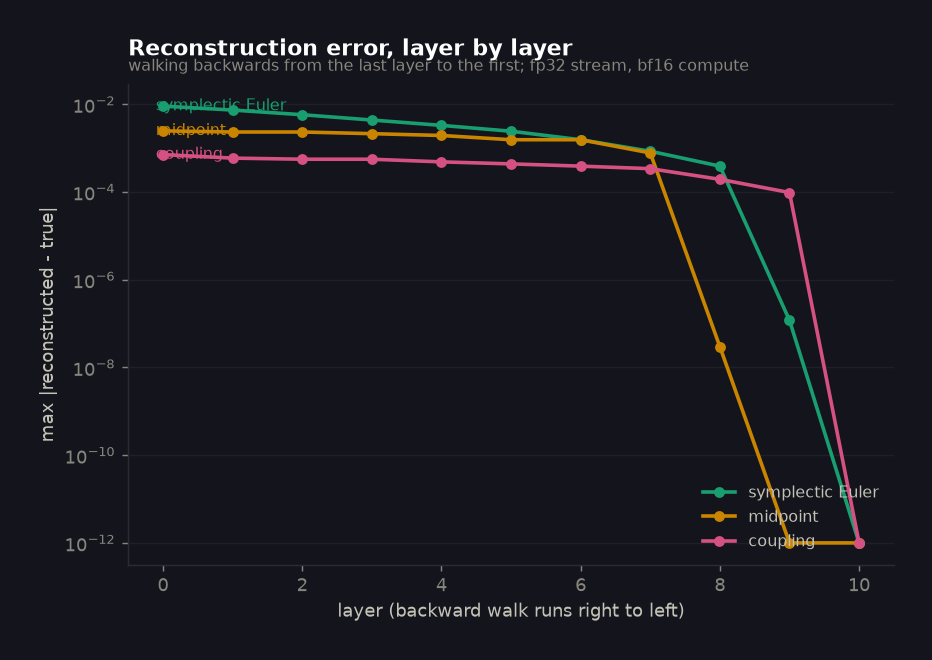

In [6]:
display(Image(plots.reconstruction_drift(drifts, OUT)))

**What you should see.** Errors around $10^{-3}$ — small, but *not zero*, and growing as
the walk goes deeper. That is not a bug, and it is worth understanding rather than
explaining away.

Floating-point addition is not associative: $(a + b) - b \neq a$ exactly. The forward
pass computed `h + 2G`; the backward computes `h_next - 2G`; the rounding of the first
is not undone by the second. Each layer adds a little, and the walk compounds it.

This is why the residual stream is carried in **fp32 while $G$ is computed in bf16**. A
bf16 stream has ~8 mantissa bits and the drift grows by roughly an order of magnitude.
The gradients are still computed against the *reconstructed* activations, so this error
is the real precision floor of the whole method.

**Takeaway.** Exactly reversible on paper, approximately reversible in floating point.
Publish the number.

## 8. The gate: are the gradients right?

Everything so far could be true and the gradients still wrong. This is the test that
matters, and it is the one most implementations skip.

We compare, in **fp64** so floating point cannot hide anything, on the *same recurrence*:

* the reversible engine's gradients (reconstructing as it goes), against
* ordinary autograd on the identical equations (storing everything).

They must agree to machine precision, for every parameter.

In [7]:
def gate_gradients(mode):
    cfg = GPTConfig(vocab_size=97, block_size=16, n_layer=6, n_head=2, n_embd=16)
    torch.manual_seed(0)
    m = GPT(cfg, mode=mode).double()
    for b in m.blocks:
        b.use_amp = False
        for sub in (getattr(b, "f", None), getattr(b, "g", None)):
            if sub is not None: sub.use_amp = False
    torch.manual_seed(1)
    idx = torch.randint(0, 97, (2, 16)); tgt = torch.randint(0, 97, (2, 16))

    refs = {  # the same maths, written so autograd can differentiate it normally
        "euler":    lambda m, h: _ref_euler(m, h),
        "midpoint": lambda m, h: _ref_mid(m, h),
        "coupling": lambda m, h: _ref_cpl(m, h),
    }
    from revlm.model import chunked_cross_entropy
    m.zero_grad(set_to_none=True)
    chunked_cross_entropy(m.ln_f(refs[mode](m, m.embed(idx))), tgt, m.head.weight, 1).backward()
    ref = {n: p.grad.clone() for n, p in m.named_parameters() if p.grad is not None}
    m.zero_grad(set_to_none=True)
    m(idx, tgt).backward()
    eng = {n: p.grad.clone() for n, p in m.named_parameters() if p.grad is not None}
    return max((ref[k] - eng[k]).abs().max().item() / max(ref[k].abs().max().item(), 1e-14)
               for k in ref)

def _ref_euler(m, h):
    v = torch.zeros_like(h)
    for b in m.blocks: v = v + b(h); h = h + v
    return h
def _ref_mid(m, h):
    hp, hc = h, h + m.blocks[0](h)
    for l in range(1, len(m.blocks)): hp, hc = hc, hp + 2.0 * m.blocks[l](hc)
    return hc
def _ref_cpl(m, h):
    x1, x2 = h.chunk(2, -1)
    for b in m.blocks: y1 = x1 + b.f(x2); x1, x2 = y1, x2 + b.g(y1)
    return torch.cat([x1, x2], -1)

for mode in ("euler", "midpoint", "coupling"):
    err = gate_gradients(mode)
    assert err < 1e-9, f"{mode} gradients are wrong: {err:.3e}"
    print(f"  {mode:<10} worst relative gradient error: {err:.3e}   PASS")
print("\n  all three engines reproduce autograd exactly")

  euler      worst relative gradient error: 6.880e-16   PASS
  midpoint   worst relative gradient error: 1.141e-15   PASS
  coupling   worst relative gradient error: 1.425e-15   PASS

  all three engines reproduce autograd exactly


**What you should see.** Errors around $10^{-15}$ — machine epsilon for fp64. Not
"close enough": *identical*.

One more check, free and worth having. Every backward walk ends on a reconstructed
$h_0$, and the true $h_0$ was kept. So every training step can verify itself:

In [8]:
cfg = GPTConfig(vocab_size=97, block_size=16, n_layer=6, n_head=2, n_embd=16)
torch.manual_seed(0)
m = GPT(cfg, mode="midpoint").double()
for b in m.blocks: b.use_amp = False
m.track_recon = True
torch.manual_seed(1)
idx = torch.randint(0, 97, (2, 16))
m(idx, idx).backward()
print(f"  end-to-end reconstruction error this step: {m.diag['recon_h0']:.3e}")
print(f"  parasitic (odd/even) mode separation:      {m.diag['parasitic']:.3e}")

  end-to-end reconstruction error this step: 1.388e-17
  parasitic (odd/even) mode separation:      5.369e-04


**Takeaway.** The reversible engines are not approximations of autograd. In exact
arithmetic they *are* autograd, and the self-check runs on every step for free.

## 9. What it costs, and what it buys

In [9]:
if DEV == "cuda":
    print(f"  {'mode':<14}{'per-batch GiB':>15}{'tok/s':>10}{'vs baseline':>13}")
    base_tps = None
    for mode in ("store", "checkpoint", "euler", "midpoint"):
        cfg = GPTConfig(n_layer=10)
        torch.manual_seed(0)
        mm = GPT(cfg, mode=mode).cuda()
        opt = torch.optim.AdamW(mm.parameters(), lr=1e-4, weight_decay=0.0)
        x = torch.randint(0, cfg.vocab_size, (16, 512), device="cuda")
        t = M.Timer(warmup=3)
        for _ in range(2): mm(x, x).backward(); opt.step(); opt.zero_grad(set_to_none=True)
        torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        base = M.allocated_gib()
        for _ in range(10):
            t.start(); mm(x, x).backward(); opt.step(); opt.zero_grad(set_to_none=True)
            t.stop(16 * 512)
        tps = t.tokens_per_sec
        base_tps = base_tps or tps
        print(f"  {mode:<14}{M.peak_gib()-base:15.3f}{tps:10.0f}{base_tps/tps:12.2f}x")
        del mm, opt, x; torch.cuda.empty_cache()

  mode            per-batch GiB     tok/s  vs baseline


  store                   1.992     96509        1.00x


  checkpoint              0.891     79330        1.22x


  euler                   0.797     74639        1.29x


  midpoint                0.797     75427        1.28x


**What you should see.** Reversibility costs roughly a **quarter** of the throughput —
one extra forward evaluation of $G$ per layer, against a baseline that does one forward
and one backward. And it buys a memory reduction that *grows with depth*, because the
baseline's cost grows with depth and reversibility's does not.

Note where checkpointing lands. It is the honest rival — recomputation without any
reversibility — and it is not far behind at ten layers. It keeps one tensor per layer
where reversibility keeps three in total, so the gap between them is `(L-3)` stream
tensors: negligible at `L=4`, decisive at `L=32`.

**Takeaway.** The trade is ~25% of your speed for memory that stops scaling with depth.
Whether that is a good deal depends entirely on whether you are memory-bound.

## 10. The part the slogan leaves out

"Reversible networks don't store activations" is true and slightly misleading. Peak
memory is `O(1)` **in depth**, not `O(1)`. Three things survive:

```text
  weights + gradients + Adam states    fixed, ~0.34 GiB at 21M params
  the boundary states                  2-3 tensors, O(batch x sequence)
  one live layer's graph               O(batch x sequence)  <- backward still needs it
  the fp32 logits in the LM head       O(batch x sequence x vocab)
```

That last line is the sting. At batch 128 the logits are
`128 x 512 x 8192 x 4 bytes = 2.1 GiB` — on their own, larger than everything
reversibility just saved. Once activations stop being the bottleneck, **the loss head
becomes the bottleneck**, and the fix is a different one (chunked cross-entropy, which
`revlm.model.chunked_cross_entropy` implements).

**Takeaway.** Reversibility does not remove the memory wall. It moves it — and you have
to go and find where it moved to.

## What to carry away

1. A pre-LN transformer **is** an Euler integrator on the depth axis. Reversibility is a
   question about which integrators run backwards.
2. **Inverting Euler directly is conditional** on $\gamma\,\mathrm{Lip}(F) < 1$ — a
   condition nothing enforces, that depends on width and sequence length, and that a
   toy-sized unit test will happily tell you is satisfied.
3. **Two states make it unconditional.** A velocity (symplectic Euler) or a memory of
   the previous layer (midpoint) both give an explicit, exact inverse for one extra
   evaluation of $G$ per layer.
4. **Check the gradients in fp64 against the same recurrence.** Anything less and a
   wrong engine looks exactly like a right one.
5. Exactly reversible on paper is **approximately** reversible in floating point.
   Measure the drift and publish it.
6. It costs ~25% of throughput, and it moves the bottleneck into the LM head.

Next: `02_train_20M_on_50M_tokens.ipynb` trains a 21M model on 50M tokens four ways and
pushes the batch size until the GPU gives up.